In [1]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
import os, warnings
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"
os.environ.pop("HF_HUB_ENABLE_HF_TRANSFER", None)
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub")


In [5]:
model, tokenizer = FastVisionModel.from_pretrained(
    "qwen_lora3",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.8.18: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.559 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

In [6]:
from datasets import load_dataset
dataset = load_dataset("5CD-AI/Viet-ComputerScience-VQA", split = "train", token = "")

Generating train split:   0%|          | 0/6899 [00:00<?, ? examples/s]

In [7]:
dataset

Dataset({
    features: ['id', 'image', 'description', 'conversations'],
    num_rows: 6899
})

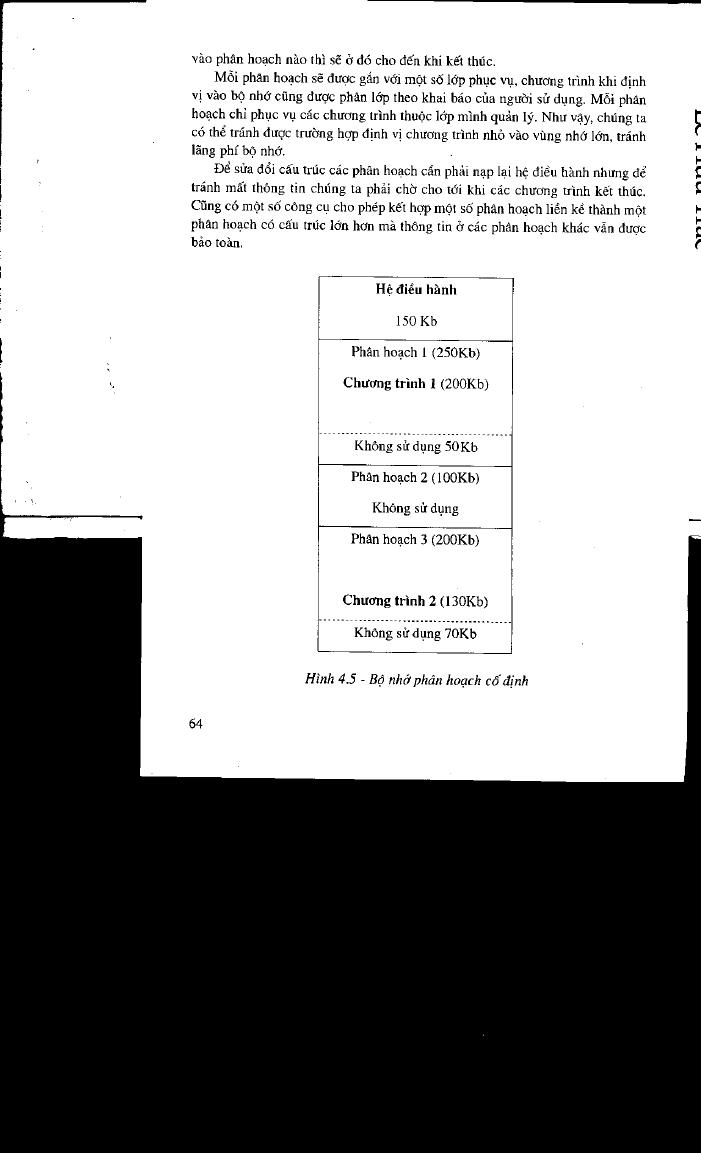

In [8]:
dataset[2]["image"]

In [9]:
dataset[2]["description"],dataset[2]["conversations"]

('Bức ảnh hiển thị một phần văn bản từ một tài liệu kỹ thuật. Văn bản mô tả cách bố trí bộ nhớ trong hệ điều hành, tập trung vào khái niệm phân hoạch bộ nhớ. Văn bản có các tiêu đề như "Hệ điều hành", "Phân hoạch 1", "Chương trình 1", "Không sử dụng", v.v. Bên cạnh đó, có một sơ đồ minh họa dạng bảng với hai cột. Cột bên trái liệt kê các thành phần như "Hệ điều hành", "Phân hoạch 1", "Chương trình 1", "Không sử dụng", "Phân hoạch 2", "Không sử dụng", "Phân hoạch 3", "Chương trình 2", "Không sử dụng". Cột bên phải thể hiện dung lượng tương ứng với mỗi thành phần, ví dụ: "Hệ điều hành" là 150 Kb, "Phân hoạch 1" là 250 Kb, "Chương trình 1" là 200 Kb, v.v. Phía dưới sơ đồ có dòng chữ "Hình 4.5 - Bộ nhớ phân hoạch cố định".',
 [{'role': 'user', 'content': 'Phân hoạch bộ nhớ là gì?'},
  {'role': 'assistant',
   'content': 'Phân hoạch bộ nhớ là một kỹ thuật quản lý bộ nhớ trong hệ điều hành. Nó chia bộ nhớ khả dụng thành các phần nhỏ hơn, được gọi là "phân hoạch", và gán cho từng chương trình

In [10]:
from torch.utils.data import Dataset

class LazyVQADataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        conversations = sample["conversations"]
        
        first_user_text = f"{sample['description']}\n\n{conversations[0]['content']}"
        
        messages = []
        for i, msg in enumerate(conversations):
            role = msg["role"]
            text_content = first_user_text if i == 0 else msg["content"]
            
            if i == 0 and role == "user":
                messages.append({
                    "role": role,
                    "content": [
                        {"type": "image", "image": sample["image"]},
                        {"type": "text", "text": text_content}
                    ]
                })
            else:
                messages.append({
                    "role": role,
                    "content": [
                        {"type": "text", "text": text_content}
                    ]
                })
                
        return { "messages" : messages }

In [11]:
dataset_split = dataset.train_test_split(test_size = 0.1, seed = 42)
train_dataset = LazyVQADataset(dataset_split["train"])
eval_dataset = LazyVQADataset(dataset_split["test"])


In [12]:
train_dataset[2]

{'messages': [{'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=700x1012>},
    {'type': 'text',
     'text': 'Bức ảnh mô tả về hệ thống mã hóa và giải mã tín hiệu với nội dung: "Trong một hệ thống m mức sẽ có m-1 mặt phân biệt nhau. Các đường ngang (trong mặt hiển thị mẫu mật) được gắn nhãn +1, 0 và -1 tương ứng với các biên độ được thu lý tưởng. Các đường thẳng đứng (trong mặt hiển thị mẫu mật) cách biệt nhau bởi chu kỳ thời gian T. tương ứng với thời gian quyết định lý tưởng. Các mức quyết định đối với bộ tái tạo tín hiệu được đặc trưng bởi các điểm giao nhau. Các điểm giao nhau với đường thẳng đứng biểu thị thời gian quyết định và các điểm giao nhau với đường ngang biểu thị mức quyết định. Mẫu mật có thể hiển thị đặc tính chất lượng về hình dạng và thời gian đối với một tập âm hoặc sai số nào đó có trong cận bằng đường dây. Trong điều kiện bình thường thì mật mở. Nếu có nhiều hoặc tạp âm thì mật sẽ khép lại. Độ mở

In [15]:
import torch
import re
import string
import Levenshtein
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter
from tqdm import tqdm
from bert_score import score

# Tải bộ ngắt câu của NLTK
nltk.download('punkt', quiet=True)
smoothie = SmoothingFunction().method1

# --- 1. Hàm chuẩn hóa văn bản ---
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(là|của|như|với)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    def lower(text):
        return str(text).lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def get_text_content(content):
    """Trích xuất chuỗi văn bản từ content (dù là list hay string)."""
    if isinstance(content, str):
        return content
    elif isinstance(content, list):
        texts = []
        for item in content:
            if isinstance(item, dict) and item.get("type") == "text":
                texts.append(item.get("text", ""))
            elif isinstance(item, str):
                texts.append(item)
        return " ".join(texts)
    return str(content)

# --- 2. Các hàm tính toán Metrics ---
def calc_f1(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    
    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)
    if num_same == 0:
        return 0.0
    
    precision = 1.0 * num_same / len(pred_tokens)
    recall = 1.0 * num_same / len(gt_tokens)
    return (2 * precision * recall) / (precision + recall)

def calc_anls(prediction, ground_truth, threshold=0.5):
    pred_norm = normalize_answer(prediction)
    gt_norm = normalize_answer(ground_truth)
    
    if not pred_norm and not gt_norm:
        return 1.0
    if not pred_norm or not gt_norm:
        return 0.0
        
    dist = Levenshtein.distance(pred_norm, gt_norm)
    max_len = max(len(pred_norm), len(gt_norm))
    
    nl = dist / max_len
    return (1.0 - nl) if nl < threshold else 0.0

def calc_bleu4(prediction, ground_truth):
    """Tính điểm BLEU-4 giữa câu dự đoán và đáp án chuẩn."""
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens or not gt_tokens:
        return 1.0 if pred_tokens == gt_tokens else 0.0
    return sentence_bleu([gt_tokens], pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

def calc_rouge_l(prediction, ground_truth):
    """Tính điểm ROUGE-L dựa trên Longest Common Subsequence (LCS)."""
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens or not gt_tokens:
        return 1.0 if pred_tokens == gt_tokens else 0.0
    
    m, n = len(gt_tokens), len(pred_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if gt_tokens[i] == pred_tokens[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i+1][j], dp[i][j+1])
    lcs = dp[m][n]
    if lcs == 0:
        return 0.0
    prec = lcs / n
    rec = lcs / m
    return (2 * prec * rec) / (prec + rec)

# --- 3. ĐÁNH GIÁ TỰ ĐỘNG ĐA LƯỢT (MULTI-TURN) ---
FastVisionModel.for_inference(model)

total_anls = 0.0
total_f1 = 0.0
total_bleu4 = 0.0
total_rouge_l = 0.0
total_evaluated_turns = 0  # Tổng số lượt câu hỏi được đánh giá

all_preds = []
all_gts = []

num_dialogues =  100  # Số lượng cuộc hội thoại muốn test
print(f"🔍 Đang đánh giá đa lượt trên {num_dialogues} hội thoại...")

for i in tqdm(range(num_dialogues)):
    sample = eval_dataset[i]
    messages_data = sample["messages"]
    
    # 1. Trích xuất hình ảnh từ câu hỏi đầu tiên
    image = None
    for msg in messages_data:
        if msg["role"] == "user" and isinstance(msg["content"], list):
            for item in msg["content"]:
                if isinstance(item, dict) and item.get("type") == "image":
                    image = item.get("image")
                    break
            if image:
                break
                
    # 2. Duyệt qua từng lượt hỏi - đáp (Cặp User - Assistant)
    for turn_idx in range(0, len(messages_data) - 1, 2):
        user_msg = messages_data[turn_idx]
        asst_msg = messages_data[turn_idx + 1]
        
        if user_msg["role"] != "user" or asst_msg["role"] != "assistant":
            continue
            
        question_text = get_text_content(user_msg["content"])
        gt_answer = get_text_content(asst_msg["content"])
        
        # 3. Xây dựng lịch sử hội thoại cho tới lượt hiện tại
        history_up_to_now = messages_data[:turn_idx + 1]
        formatted_history = []
        
        for idx, msg in enumerate(history_up_to_now):
            role = msg["role"]
            text = get_text_content(msg["content"])
            if role == "user":
                if idx == 0:
                    formatted_history.append({
                        "role": "user",
                        "content": [{"type": "image"}, {"type": "text", "text": text}]
                    })
                else:
                    formatted_history.append({
                        "role": "user",
                        "content": text
                    })
            elif role == "assistant":
                formatted_history.append({
                    "role": "assistant",
                    "content": text
                })
        
        # 4. Tokenize & Model Generate
        input_text = tokenizer.apply_chat_template(formatted_history, add_generation_prompt=True)
        inputs = tokenizer(image, input_text, add_special_tokens=False, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            output_ids = model.generate(
                **inputs, 
                max_new_tokens=256,
                use_cache=True, 
                temperature=0.1, 
                do_sample=False
            )
            
        pred_answer = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        # 5. Lưu kết quả & Tính toán điểm cho lượt này
        all_preds.append(pred_answer)
        all_gts.append(gt_answer)

        anls = calc_anls(pred_answer, gt_answer)
        f1 = calc_f1(pred_answer, gt_answer)
        bleu4 = calc_bleu4(pred_answer, gt_answer)
        rouge_l = calc_rouge_l(pred_answer, gt_answer)

        total_anls += anls
        total_f1 += f1
        total_bleu4 += bleu4
        total_rouge_l += rouge_l
        total_evaluated_turns += 1

        if total_evaluated_turns <= 3:
            print(f"\n--- [Hội thoại {i+1} - Lượt {(turn_idx//2)+1}] ---")
            print(f"❓ Hỏi: {question_text}")
            print(f"✅ Chuẩn: {gt_answer}")
            print(f"🤖 Đoán : {pred_answer}")
            print(f"🎯 ANLS: {anls:.2f} | F1: {f1:.2f} | BLEU-4: {bleu4:.2f} | ROUGE-L: {rouge_l:.2f}")

# --- 4. TÍNH TOÁN BERTSCORE ---
print("\n🧠 Đang tính toán BERTScore trên toàn bộ các lượt...")
P, R, F1_bert = score(all_preds, all_gts, lang="vi", verbose=True) 
avg_bert_f1 = F1_bert.mean().item()

# --- 5. IN KẾT QUẢ TỔNG HỢP TẤT CẢ CÁC LƯỢT ---
print("\n" + "="*55)
print(f" KẾT QUẢ ĐÁNH GIÁ VQA ĐA LƯỢT ({total_evaluated_turns} lượt câu hỏi):")
print(f" Average ANLS Score       : {total_anls / total_evaluated_turns * 100:.2f}%")
print(f" Average F1-Score         : {total_f1 / total_evaluated_turns * 100:.2f}%")
print(f" Average BLEU-4           : {total_bleu4 / total_evaluated_turns * 100:.2f}%")
print(f" Average ROUGE-L          : {total_rouge_l / total_evaluated_turns * 100:.2f}%")
print(f" Average BERTScore        : {avg_bert_f1 * 100:.2f}%")
print("="*55)


🔍 Đang đánh giá đa lượt trên 100 hội thoại...


  0%|          | 0/100 [00:00<?, ?it/s]


--- [Hội thoại 1 - Lượt 1] ---
❓ Hỏi: Bức ảnh chụp một phần tài liệu hướng dẫn về lập trình C#.  Phần bên trái hiển thị các đoạn mã lệnh C#  có chú thích chi tiết về các thành phần của Form:  Graphics,  OnPaint,  PrintPage,  Form,  ComponentModel và Components. Phần bên phải hiển thị nội dung  liên quan đến  Phương thức xử lý giao diện đồ họa (GUI)  được trình bày trong phần  'Chương 3-2' của tài liệu, bao gồm: 

- Phương thức cho phép truy cập hiển thị của lớp  'ppView'.
- Phương thức  'MDIChildForm'  và  'InitializeComponent'  gồm các đoạn mã để thiết lập các thuộc tính như  'Location', 'Size', 'AnchorStyles', và  'Controls'.
-  Phương thức 'Dispose'  với chú thích 'Giải phóng tài nguyên'.
-   Chú thích  'Phương thức hỗ trợ cho Designer'  và  'Dung thay đổi phương thức này trong các sửa soạn thảo code của môi trường phát triển'.

Phần dưới cùng của ảnh là một phần của ảnh khác, không liên quan đến nội dung chính của ảnh, hiển thị  tiêu đề 'Xây dựng với các thành phần  Windows Forms'

100%|██████████| 100/100 [1:24:52<00:00, 50.92s/it]



🧠 Đang tính toán BERTScore trên toàn bộ các lượt...


...

calculating scores...
computing bert embedding.


  0%|          | 0/16 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/8 [00:00<?, ?it/s]

done in 3.95 seconds, 126.42 sentences/sec

 KẾT QUẢ ĐÁNH GIÁ VQA ĐA LƯỢT (500 lượt câu hỏi):
 Average ANLS Score       : 33.64%
 Average F1-Score         : 64.73%
 Average BLEU-4           : 40.71%
 Average ROUGE-L          : 57.08%
 Average BERTScore        : 85.70%
